#Fake News Classification using Naive Bayes algorithm with TextFrequency-InverseDocumentFrequency(TF-IDF)

##Data Collection

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


Dataset\
Size - 11 MB\
Link - https://www.kaggle.com/datasets/biswasangela/fakenews

In [ ]:
import pandas as pd
path = '/content/drive/MyDrive/Internship Archive/Tasks(DataScience)/Project/news_articles.csv'
df = pd.read_csv(path)

In [ ]:
df.sample()

,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
2058,Jay Baggett,2016-10-27T04:07:44.743+03:00,men cry rape by irans top quran reader,NaN,english,wnd.com,http://www.wnd.com/files/2016/10/Hero1.jpg,bias,Real,judge warns dangers appointed judiciary,NaN,1.0


In [ ]:
df.head()

,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,muslims busted stole millions govt benefits,print pay back money plus interest entire fami...,1.0
1,reasoning with facts,2016-10-29T08:47:11.259+03:00,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,1.0
2,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,1.0
3,Fed Up,2016-11-01T05:22:00.000+02:00,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,pin drop speech father daughter kidnapped kill...,email kayla mueller prisoner tortured isis cha...,1.0
4,Fed Up,2016-11-01T21:56:00.000+02:00,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,fantastic trumps point plan reform healthcare ...,email healthcare reform make america great sin...,1.0


In [ ]:
df['language'].unique()

array(['english', 'ignore', 'german', 'french', 'spanish', nan],
      dtype=object)

##Data Inspection

###Collective Inspection

In [ ]:
print("Data Types:")
display(df.dtypes)
print("rows, columns:")
display(df.shape)

Data Types:


,0
author,object
published,object
title,object
text,object
language,object
site_url,object
main_img_url,object
type,object
label,object
title_without_stopwords,object


rows, columns:


(2096, 12)

In [ ]:
#There are 2096 rows in the dataset
#11 columns are object and 1 column is float64 datatypes.

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
df['label'].unique()

array(['Real', 'Fake', nan], dtype=object)

In [ ]:
df['type'].unique()

array(['bias', 'conspiracy', 'fake', 'bs', 'satire', 'hate', 'junksci',
       'state', nan], dtype=object)

In [ ]:
#author - name of the news outlet
#published - date and time of publishing
#title - news headline
#text - news content
#language - the language used in the news
#site_url - publisher website address
#main_img_url - image hosted address
#type - category of news by emotional judgement
#label - if news is real or fake
#title_without_stopwords - headline with only unique parts of speech
#text_without_stopwords - content with only unique parts of speech
#hasImage - if the news contains image or not

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2096 entries, 0 to 2095
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   author                   2096 non-null   object 
 1   published                2096 non-null   object 
 2   title                    2096 non-null   object 
 3   text                     2050 non-null   object 
 4   language                 2095 non-null   object 
 5   site_url                 2095 non-null   object 
 6   main_img_url             2095 non-null   object 
 7   type                     2095 non-null   object 
 8   label                    2095 non-null   object 
 9   title_without_stopwords  2094 non-null   object 
 10  text_without_stopwords   2046 non-null   object 
 11  hasImage                 2095 non-null   float64
dtypes: float64(1), object(11)
memory usage: 196.6+ KB


In [ ]:
#Remove 'main_img_url' column.
#The 'published' column must be converted into time data type(from object).

In [ ]:
df.isna().sum()

,0
author,0
published,0
title,0
text,46
language,1
site_url,1
main_img_url,1
type,1
label,1
title_without_stopwords,2


In [ ]:
#There are missing values in columns 'text', 'text_without_stopwords', 'title_without_stopwords', 'label', 'type', 'main_img_url', 'site_url', 'language'.
#Columns with only single null values are all in the same row.

In [ ]:
df.duplicated().sum()

np.int64(10)

In [ ]:
#There are 10 duplicate rows

In [ ]:
df.describe(include='object')

,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords
count,2096,2096,2096,2050,2095,2095,2095,2095,2095,2094,2046
unique,491,2006,1784,1941,5,68,1229,8,2,1780,1937
top,No Author,2016-11-01T13:00:00.000+02:00,no title,notify me of followup comments by email notify...,english,frontpagemag.com,No Image URL,bs,Fake,title,notify followup comments email notify new post...
freq,505,8,186,6,2017,100,466,601,1294,187,6


In [ ]:
df['hasImage'].value_counts()

,count
hasImage,
1.0,1628
0.0,467


In [ ]:
#About 1/4 news outlets have no author
#Almost all of the news are in english except a spare few
#There are 491 authors, but only 68 site_url
#frontpagemag.com is the most appearing site_url
#More than half the news in the dataset is fake news
#467 news pages have no image attached
#187 news pages have no title.

In [ ]:
df[df['title_without_stopwords'].isnull()]

,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
374,Daniel Haiphong,2016-11-17T02:00:00.000+02:00,won now what,the syrian army and hezbollah resistance force...,english,ahtribune.com,http://ahtribune.com/images/media/Donald_Trump...,bs,Fake,NaN,syrian army hezbollah resistance forces contin...,1.0
2095,Eddy Lavine,2016-10-28T01:02:00.000+03:00,cannabis aficionados develop thca crystalline ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# 'title_without_stopwords' column at index 374 and 2095 have null values.
# row 2095 can be removed as it has 9 null columns.

In [ ]:
df[(df['text_without_stopwords'].isnull() == True) & (df['text'].isnull() == False)]

,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
2046,-NO AUTHOR-,2016-10-27T03:05:07.528+03:00,gingrich slutshames megyn kelly,good samaritan wearing indian headdress disarm...,english,wnd.com,No Image URL,bias,Real,hillarys emails might missing,NaN,1.0
2047,Jerome R. Corsi,2016-10-27T03:05:08.609+03:00,youtube bans clintons black son,skype sex scam a fortune built on shame moroc...,english,wnd.com,http://www.wnd.com/files/2016/10/hillary_shock...,bias,Real,hillarys emails might missing,NaN,1.0
2048,Leo Hohmann,2016-10-27T03:12:09.534+03:00,wikileaks bombshells on hillary you need to know,posted by eddie while the skyhigh potency may ...,english,wnd.com,http://mobile.wnd.com/files/2016/10/hillary_sh...,bias,Real,wikileaks bombshells hillary need know,NaN,1.0
2049,-NO AUTHOR-,2016-10-27T03:12:13.906+03:00,fascinated with sex,billion even after they are known to be keepin...,english,wnd.com,http://mobile.wnd.com/files/2015/10/Hillary-Cl...,bias,Real,fascinated sex,NaN,0.0


In [ ]:
#There are 4 rows where 'text' has value but 'text_without_stop' words doesn't
#2 of them have contradicting titles and titles_without_stopwords
#46 rows have null in 'title' column

In [ ]:
#10 duplicated rows

###Individual Inspection

In [ ]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')

In [ ]:
display(df['type'].value_counts(ascending=True,normalize=True).mul(100).round(2).astype(str)+'%')

,proportion
type,
fake,0.72%
junksci,4.87%
state,5.78%
satire,6.97%
hate,11.65%
conspiracy,20.53%
bias,20.81%
bs,28.69%


In [ ]:
fake_label,fake_type = 0,0
for x in df.index:
  if df.loc[x,'type'] == 'fake':
    if df.loc[x,'label'] == 'Fake':
      fake_label+=1
    fake_type+=1
print(fake_label,"out of",fake_type, " news of type 'fake' have label 'Fake'")

15 out of 15  news of type 'fake' have label 'Fake'


In [ ]:
#df[df['type']=='fake']

In [ ]:
#Type column has 'fake' as a unique value, but it must be changed to suit the news content since only 15 are such rows.

In [ ]:
legitamacy_byimage = df.groupby('hasImage')['label'].agg(['value_counts'])
legitamacy_byimage.reset_index(inplace=True)
legitamacy_byimage.drop(columns=['hasImage'],inplace=True)
legitamacy_byimage['label']= ['Fake_News_no_Image','Real_News_no_Image','Fake_News_has_Image','Real_News_has_Image']
legitamacy_byimage.rename(columns={'label':'News Page', 'value_counts':'count'},inplace=True)

display(legitamacy_byimage)

,News Page,count
0,Fake_News_no_Image,341
1,Real_News_no_Image,126
2,Fake_News_has_Image,953
3,Real_News_has_Image,675


In [ ]:
print("Presence of image increase probablity of fake news by" ,round((341/953*100), ndigits=2),"% and real news by",round((126/675*100),ndigits=2),"%")

Presence of image increase probablity of fake news by 35.78 % and real news by 18.67 %


In [ ]:
fake_articles_by_author = df[df['label'] == 'Fake'].groupby('author').size().reset_index(name='fake_article_count')
fake_articles_by_author = fake_articles_by_author.sort_values(by='fake_article_count', ascending=False)#can also use nlargest(10) alternatively
Fake_authors_top10 = fake_articles_by_author.head(10) #top 10 fake news publishers for bar/countplot

total_realArticle_authors = df['author'].nunique()
total_fakeArticle_authors = fake_articles_by_author['author'].nunique()

print(f"\n{total_fakeArticle_authors} authors out of {total_realArticle_authors} have published fake news")



303 authors out of 491 have published fake news


##Data Preprocessing

###Data Cleaning

In [ ]:
#removing irrelevant columns
df.drop(columns=['main_img_url'], inplace=True)

In [ ]:
#row with too many null values
df[df['language'].isnull()]

,author,published,title,text,language,site_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
2095,Eddy Lavine,2016-10-28T01:02:00.000+03:00,cannabis aficionados develop thca crystalline ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.drop(index=2095,inplace=True)

In [ ]:
#rows with null
df[df['title_without_stopwords'].isnull()]

,author,published,title,text,language,site_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
374,Daniel Haiphong,2016-11-17T02:00:00.000+02:00,won now what,the syrian army and hezbollah resistance force...,english,ahtribune.com,bs,Fake,NaN,syrian army hezbollah resistance forces contin...,1.0


In [ ]:
df.loc[374,'title_without_stopwords'] = 'won'

In [ ]:
#rows that need stopword removal
df[(df['text'].isnull() == False) & (df['text_without_stopwords'].isnull() == True)]

,author,published,title,text,language,site_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
2046,-NO AUTHOR-,2016-10-27T03:05:07.528+03:00,gingrich slutshames megyn kelly,good samaritan wearing indian headdress disarm...,english,wnd.com,bias,Real,hillarys emails might missing,NaN,1.0
2047,Jerome R. Corsi,2016-10-27T03:05:08.609+03:00,youtube bans clintons black son,skype sex scam a fortune built on shame moroc...,english,wnd.com,bias,Real,hillarys emails might missing,NaN,1.0
2048,Leo Hohmann,2016-10-27T03:12:09.534+03:00,wikileaks bombshells on hillary you need to know,posted by eddie while the skyhigh potency may ...,english,wnd.com,bias,Real,wikileaks bombshells hillary need know,NaN,1.0
2049,-NO AUTHOR-,2016-10-27T03:12:13.906+03:00,fascinated with sex,billion even after they are known to be keepin...,english,wnd.com,bias,Real,fascinated sex,NaN,0.0


In [ ]:
try:
  from gensim.parsing.preprocessing import remove_stopwords
except ModuleNotFoundError:
  !pip install gensim
  from gensim.parsing.preprocessing import remove_stopwords

for x in range(2046,2050,1):
  print("index",x)
  print("original value:",df.loc[x,'text_without_stopwords'])
  df.loc[x,'text_without_stopwords'] = remove_stopwords(df.loc[x,'text'])
  print("changed value:",df.loc[x,'text_without_stopwords'][:20])

index 2046
original value: nan
changed value: good samaritan weari
index 2047
original value: nan
changed value: skype sex scam fortu
index 2048
original value: nan
changed value: posted eddie skyhigh
index 2049
original value: nan
changed value: billion known keepin


In [ ]:
df.dropna(inplace=True)#removing 45 rows with missing values in 'text' and 'text_without_stopwords'

In [ ]:
df.isna().sum()

,0
author,0
published,0
title,0
text,0
language,0
site_url,0
type,0
label,0
title_without_stopwords,0
text_without_stopwords,0


In [ ]:
df.drop_duplicates(inplace=True) #removal of duplicates
df.duplicated().sum()

0

In [ ]:
df['published']

,published
0,2016-10-26T21:41:00.000+03:00
1,2016-10-29T08:47:11.259+03:00
2,2016-10-31T01:41:49.479+02:00
3,2016-11-01T05:22:00.000+02:00
4,2016-11-01T21:56:00.000+02:00
...,...
2045,2016-10-27T03:05:05.815+03:00
2046,2016-10-27T03:05:07.528+03:00
2047,2016-10-27T03:05:08.609+03:00
2048,2016-10-27T03:12:09.534+03:00


In [ ]:
df['published']=pd.to_datetime(df['published'],format='mixed',errors='coerce', dayfirst=True)
df['published']
#NOTE: if I use df['published'].dtype, the type is 'O' and NaT values are introduced.

/tmp/ipython-input-439-1295349437.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['published']=pd.to_datetime(df['published'],format='mixed',errors='coerce', dayfirst=True)


,published
0,2016-10-26 21:41:00+03:00
1,2016-10-29 08:47:11.259000+03:00
2,2016-10-31 01:41:49.479000+02:00
3,2016-11-01 05:22:00+02:00
4,2016-11-01 21:56:00+02:00
...,...
2045,2016-10-27 03:05:05.815000+03:00
2046,2016-10-27 03:05:07.528000+03:00
2047,2016-10-27 03:05:08.609000+03:00
2048,2016-10-27 03:12:09.534000+03:00


In [ ]:
df['label'].replace({'Fake':1,'Real':0},inplace=True)
df.columns = df.columns.str.replace('label','is_fake')

/tmp/ipython-input-440-962844997.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['label'].replace({'Fake':1,'Real':0},inplace=True)
/tmp/ipython-input-440-962844997.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'].replace({'Fake':1,'Real':0},inplace=True)


In [ ]:
df['hasImage'].astype('int64')
#converted the 'is_fake' and 'hasImage' into int64 data type.

,hasImage
0,1
1,1
2,1
3,1
4,1
...,...
2045,0
2046,1
2047,1
2048,1


In [ ]:
#handling 'fake' value in type column
df[df['type']=='fake']

,author,published,title,text,language,site_url,type,is_fake,title_without_stopwords,text_without_stopwords,hasImage
57,Jimmy Rustling,2016-10-27 13:00:00+03:00,the amish in america commit their vote to dona...,share president obama has signed an executive...,english,abcnews.com.co,fake,1,amish america commit vote donald trump mathema...,share president obama signed executive order d...,1.0
58,Jimmy Rustling,2016-11-11 12:00:00+02:00,obama signs executive order declaring investig...,united states marine field mcconnell plum cit...,english,abcnews.com.co,fake,1,obama signs executive order declaring investig...,united states marine field mcconnell plum city...,1.0
314,"Day of the Dead 2015: History, food and reflec...",2016-10-27 05:18:00+03:00,comment on halloween in the castro returns in ...,adobochron comment comerford \nwashington dc ...,english,adobochronicles.com,fake,1,comment halloween castro returns day dead hist...,adobochron comment comerford washington dc ado...,1.0
315,Ivan Jose,2016-10-27 09:18:46.193000+03:00,comment on tutorial riding the philippine jeep...,adobochron comments a rendering of the trump ...,english,adobochronicles.com,fake,1,comment tutorial riding philippine jeepney iva...,adobochron comments rendering trump tower maka...,1.0
316,Tony Rabon,2016-10-28 19:56:09.149000+03:00,comment on what white house executive chef com...,adobochron comment \nsan francisco california...,english,adobochronicles.com,fake,1,comment white house executive chef comerford w...,adobochron comment san francisco california ad...,1.0
317,Shirley Barnett,2016-11-02 22:41:00+02:00,comment on philippines voids building permit o...,adobochron comments \nmanila philippines the...,english,adobochronicles.com,fake,1,comment philippines voids building permit trum...,adobochron comments manila philippines adobo c...,1.0
318,?????? ???? ???? ?????????,2016-11-04 22:17:00+02:00,comment on hillary clinton campaign logo has a...,adobochron comments the trump hotels in las v...,english,adobochronicles.com,fake,1,comment hillary clinton campaign logo sublimin...,adobochron comments trump hotels las vegas lef...,1.0
319,adobochron,2016-11-06 23:48:58.529000+02:00,comment on philippine government to take back ...,adobochron comments comerford \nwashington dc...,english,adobochronicles.com,fake,1,comment philippine government take back intern...,adobochron comments comerford washington dc ad...,1.0
320,Rebecca Bennett,2016-11-12 00:27:00+02:00,comment on if elected president donald trump w...,adobochron comment moyers \nwashington dc th...,english,adobochronicles.com,fake,1,comment elected president donald trump live wh...,adobochron comment moyers washington dc adobo ...,1.0
321,Eligio Abellera,2016-11-15 18:56:14.861000+02:00,comment on white house executive chef reveals ...,adobochron comment comerford left and deen \n...,english,adobochronicles.com,fake,1,comment white house executive chef reveals oba...,adobochron comment comerford left deen washing...,1.0


In [ ]:
df['type'].unique()

array(['bias', 'conspiracy', 'fake', 'bs', 'satire', 'hate', 'junksci',
       'state'], dtype=object)

In [ ]:
#replacing for rarest actual types first
df.loc[325,'type']= 'satire'
df.loc[324,'type']= 'bs'
#replacing other fake types to 'state'
for i in df.index:
  if df.loc[i,'type'] == 'fake':
    df.loc[i,'type'] = 'state'

In [ ]:
df.loc[326,'type']

'state'

In [ ]:
#row of index 326 proves that rest of 'fake' types are changed to 'state'

###Exploratory Data Analysis

In [ ]:
df.columns

Index(['author', 'published', 'title', 'text', 'language', 'site_url', 'type',
       'is_fake', 'title_without_stopwords', 'text_without_stopwords',
       'hasImage'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#univariate plots

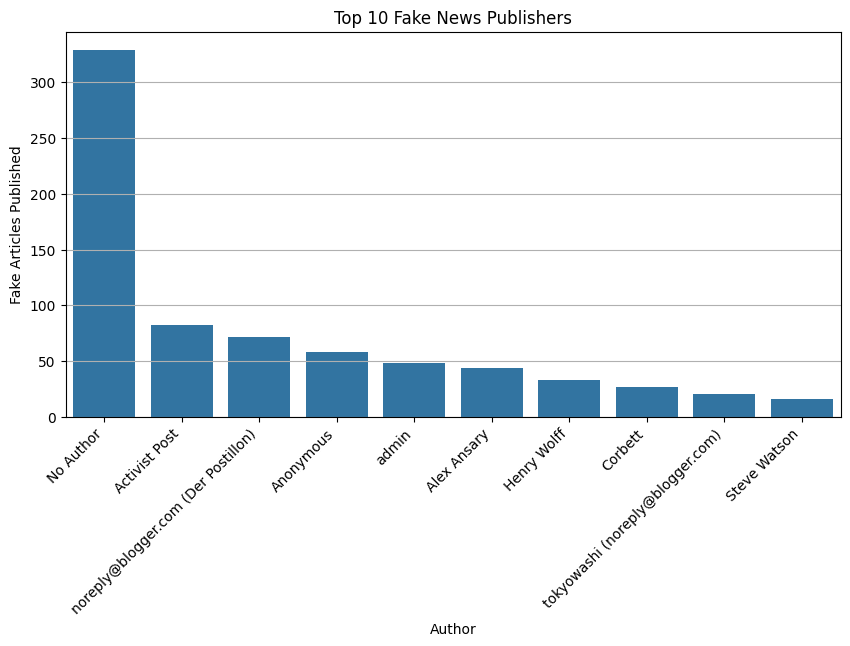

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x = Fake_authors_top10['author'], y = Fake_authors_top10['fake_article_count'])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.title('Top 10 Fake News Publishers')
plt.xlabel('Author')
plt.ylabel('Fake Articles Published')
plt.show()

In [ ]:
#Highest amount of fake news originate from  dis-credited authors
#Activist Post, Der Postillon and Anonumous authour post more than 50 fake news

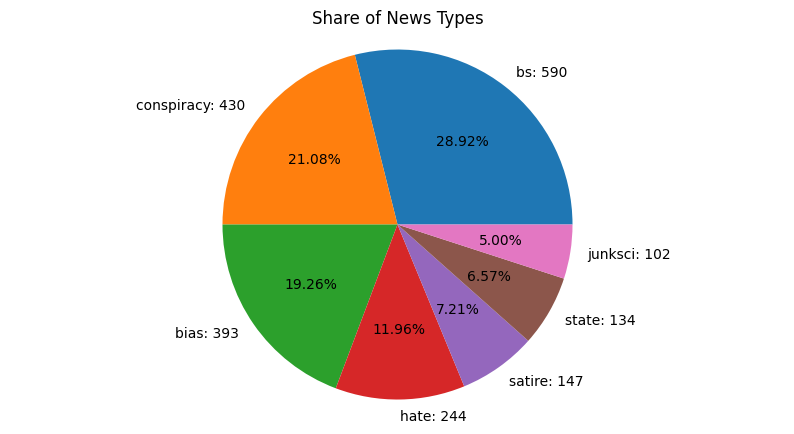

In [ ]:
plt.figure(figsize=(10,5))
news_types = df['type'].value_counts()
labela = [f'{type}: {articles}' for type, articles in news_types.items()]
plt.pie(x=news_types, labels=labela, autopct='%.2f%%')
plt.title('Share of News Types')
plt.axis('equal')
plt.show()

In [ ]:
#'bs' has most share in news while 'junksci' has the least share
#69% of the news in dataset are bs,conspiracy and bias

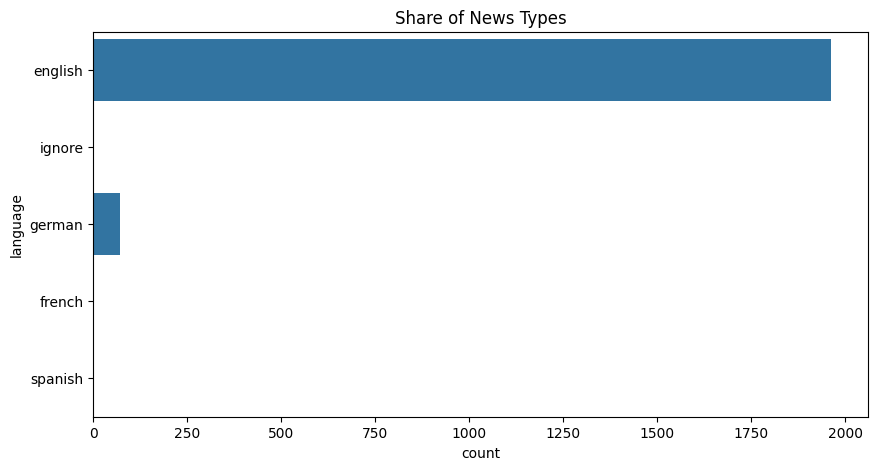

In [ ]:
plt.figure(figsize=(10,5))
news_languages = df['language']
sns.countplot(data=news_languages)
plt.title('Share of News Types')
plt.show()

In [ ]:
#english and german have considerable usage in the news

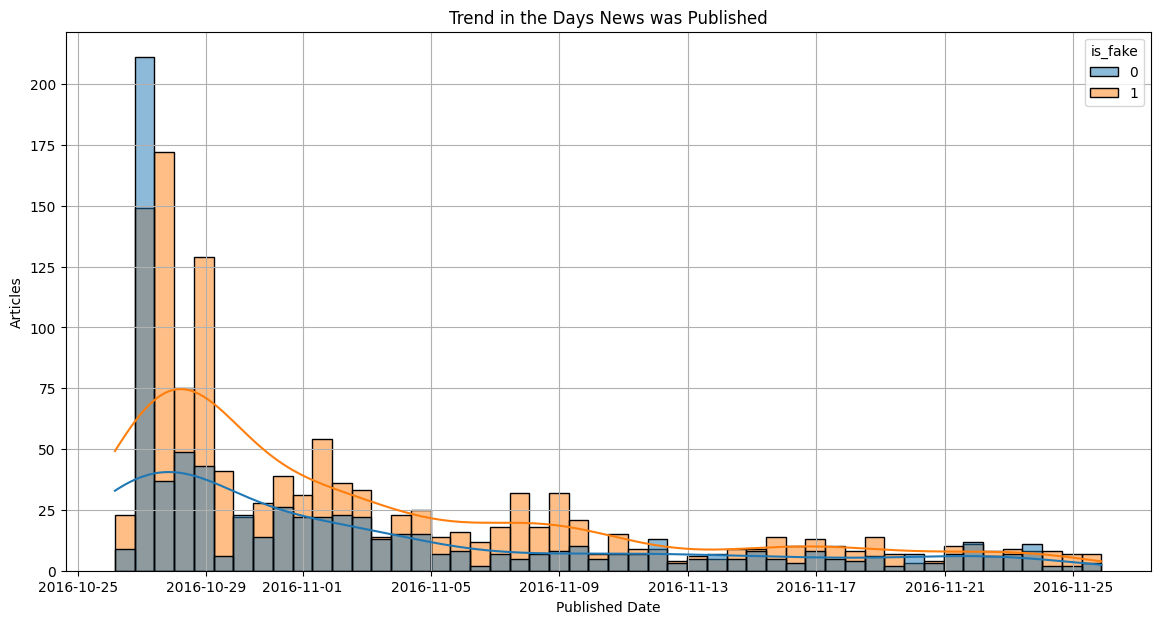

In [ ]:
plt.figure(figsize=(14, 7))
sns.histplot(data=df,hue='is_fake', x='published', kde=True, bins=50, fill=True )
plt.grid(plt.axes)
plt.title('Trend in the Days News was Published')
plt.xlabel('Published Date')
plt.ylabel('Articles')
plt.show()

In [ ]:
#There is a surge of news activity from 10-25 to 10-29
#legitimate news slowly decreased and served as a bait for a steady stream of fake news.

In [ ]:
#Data Preprocessing completed.

##ML Model identification

In [ ]:
#Naive Bayes is a probablity distribution for categorical outputs
#Naive Bayes algorithm: P(A|B)=[P(B|A)*P(A)]/P(B) ; where B is evidence and A is hypothesis and the probablity of hypothesis being true depends on prior/ older evidences
#Algorithm for spam filtering, medical diagnosis and text classification

In [ ]:
#TF-IDF stands for Term Frequency(text occurance) and Inverse Document Frequency(text rarity)
#This algorithm is used in NLP to convert text to numerical features

In [ ]:
#One hot encoding
df = pd.get_dummies(df, columns=['type'])

In [ ]:
# Create a dictionary mapping language to integer(label encoding) based on frequency
language_counts = df['language'].value_counts()
language_mapping = {lang: i for i, (lang, count) in enumerate(language_counts.items())}
df['language'] = df['language'].map(language_mapping)
display(df['language'].value_counts().reset_index())

,language,count
0,0,1962
1,1,72
2,2,3
3,3,2
4,4,1


In [ ]:
print(df.columns)

Index(['author', 'published', 'title', 'text', 'language', 'site_url',
       'is_fake', 'title_without_stopwords', 'text_without_stopwords',
       'hasImage', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate',
       'type_junksci', 'type_satire', 'type_state'],
      dtype='object')


In [ ]:
#Labels are encoded successfully

##Model Training

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
feature_columns = [
    'text_without_stopwords',
    'title_without_stopwords',
    'language',
    'type_bias',
    'type_bs',
    'type_conspiracy',
    'type_hate',
    'type_junksci',
    'type_satire',
    'type_state',
    'hasImage'
]

X = df[feature_columns]
y = df['is_fake']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

#create an instamce fpr tf-idf on text content
tfidf_vectorizer_text = TfidfVectorizer(max_features=5000)
# Fit and transform the text data in the training set
X_train_text_tfidf = tfidf_vectorizer_text.fit_transform(X_train['text_without_stopwords'].astype(str))
# Transform the text data in the testing set
X_test_text_tfidf = tfidf_vectorizer_text.transform(X_test['text_without_stopwords'].astype(str))


#create an instamce fpr tf-idf on text content
tfidf_vectorizer_title = TfidfVectorizer(max_features=1000)
# Fit and transform the title data in the training set
X_train_title_tfidf = tfidf_vectorizer_title.fit_transform(X_train['title_without_stopwords'].astype(str))
# Transform the title data in the testing set
X_test_title_tfidf = tfidf_vectorizer_title.transform(X_test['title_without_stopwords'].astype(str))


# Get the non-text features and convert boolean and float columns to integer
X_train_other_features = X_train[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)
X_test_other_features = X_test[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)


# Convert other features to dense format, which is necessary for combining td-idf matrices with sparse
X_train_other_features_dense = X_train_other_features.values
X_test_other_features_dense = X_test_other_features.values


# Combine the TF-IDF features with the other selected features
X_train_combined = sp.hstack([X_train_text_tfidf, X_train_title_tfidf, X_train_other_features_dense])
X_test_combined = sp.hstack([X_test_text_tfidf, X_test_title_tfidf, X_test_other_features_dense])


print("Text vectorization and feature combination complete.")
print("X_train_combined shape:", X_train_combined.shape)
print("X_test_combined shape:", X_test_combined.shape)

Text vectorization and feature combination complete.
X_train_combined shape: (1632, 6009)
X_test_combined shape: (408, 6009)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_combined, y_train)

print("Model trained")

Model trained


###Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Predict on the test set
y_pred = model.predict(X_test_combined)

#Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Model Evaluation:")

print(f"Accuracy: {accuracy:.4f}")   #accuracy is the ratio of correct classification (both positive(1) and negative(0)) with the total classifications performed; Use case- use to analyze overall performance in datasets where the classes have balenced weight. i.e. not used for datasets with majority and minority classes.
print(f"Precision: {precision:.4f}") #precision is the number of correct positive classifications done among the total of all positive classification; Use case- When case of False Positive is high. e.g. spam detection.
print(f"Recall: {recall:.4f}")       #correct positive classifications from total classification predicted; Use case- When cost of False Negative is high. e.g. Fraud detection.
print(f"F1-score: {f1:.4f}")         #[2*(precision * accuracy)]/(precision + accuracy); Use case- used where analyzing accuracy alone is misleading Used for classification models.

#classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.9902
Precision: 1.0000
Recall: 0.9848
F1-score: 0.9924

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       144
           1       1.00      0.98      0.99       264

    accuracy                           0.99       408
   macro avg       0.99      0.99      0.99       408
weighted avg       0.99      0.99      0.99       408



In [ ]:
#The model has gugg accurace and F1-score

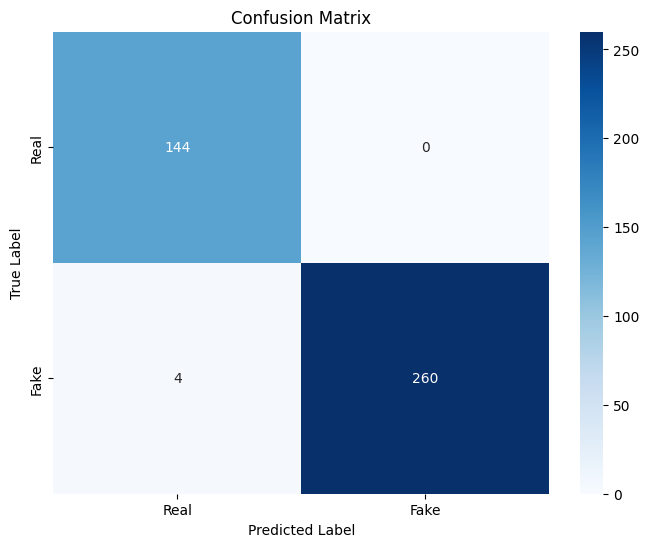

In [ ]:
#confusion matrix - this compares correct predictions(TP,TN) with incorrect predictions(FP,FN)
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
#The true positive and true negative predictions are high, and hence the high accuracy.

###Model Prediction

In [ ]:
feature_columns

['text_without_stopwords',
 'title_without_stopwords',
 'language',
 'type_bias',
 'type_bs',
 'type_conspiracy',
 'type_hate',
 'type_junksci',
 'type_satire',
 'type_state',
 'hasImage']

In [ ]:
#creating new samples and features
sample_list = [
    [
      #News content
      "sample text without stopwords", "sample title without stopwords",
      #Language
      0, # Label Encoded: 0 - english, 1 - german ...
      #type of news
      0, 0, 0, 0, 0, 0, 0,   # One hot Encoding
      #has/no image
      1
    ],
    # Sample 2
    [
        "At least 12 dead in major blast at Telangana chemical factory, several still trapped", "At least 12 people died and 36 were injured in a reactor blast at a chemical factory in Sangareddy district of Telangana on Monday. The incident took place between duty hours at Sigachi Chemicals in Pashamylaram industrial area. According to sources, there were a total of 61 people in the building when the blast took place, and several are still trapped inside.'Some of those among the rescued are critically injured. We have not ascertained how many people are trapped inside,' a police source said.",
        0, # Assuming English language
        0, 0, 0, 0, 0, 0,
        1, #settig type_state to 1
        0  # Example: setting hasImage to 0
    ]
]

In [ ]:
# Convert the sample list to a pandas DataFrame for easier processing
sample_df = pd.DataFrame(sample_list, columns=feature_columns)

# Apply the trained TF-IDF vectorizers to the sample text and title data
sample_text_tfidf = tfidf_vectorizer_text.transform(sample_df['text_without_stopwords'].astype(str))
sample_title_tfidf = tfidf_vectorizer_title.transform(sample_df['title_without_stopwords'].astype(str))
# Get the non-text features and convert them to dense format
sample_other_features = sample_df[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)
sample_other_features_dense = sample_other_features.values
# Combine the TF-IDF features with the other selected features for the sample data
sample_combined = sp.hstack([sample_text_tfidf, sample_title_tfidf, sample_other_features_dense])

# Make predictions on the combined sample data
predictions = model.predict(sample_combined)
# Display the predictions (0 for Real, 1 for Fake)
print("Predictions for the sample news articles:", predictions)

Predictions for the sample news articles: [1 0]


In [ ]:
#The predictions for sample 1,2 : TruePositive(fakenews ), TrueNegative(real news)

##Deployment

In [ ]:
def FakeNewsClassification_sample(sample_list):
  sample_df = pd.DataFrame(sample_list, columns=feature_columns)
  sample_text_tfidf = tfidf_vectorizer_text.transform(sample_df['text_without_stopwords'].astype(str))
  sample_title_tfidf = tfidf_vectorizer_title.transform(sample_df['title_without_stopwords'].astype(str))
  sample_other_features = sample_df[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)
  sample_other_features_dense = sample_other_features.values
  sample_combined = sp.hstack([sample_text_tfidf, sample_title_tfidf, sample_other_features_dense])
  predictions = model.predict(sample_combined)
  return (predictions)
print(predictions)

[1 0]


In [ ]:
import joblib

# Save the trained Naive Bayes model
joblib.dump(model, 'naive_bayes_model.joblib')

# Save the TF-IDF vectorizer for text
joblib.dump(tfidf_vectorizer_text, 'tfidf_vectorizer_text.joblib')

# Save the TF-IDF vectorizer for title
joblib.dump(tfidf_vectorizer_title, 'tfidf_vectorizer_title.joblib')

# Save the prediction function
joblib.dump(FakeNewsClassification_sample, 'fake_news_prediction_function.joblib')

print("Model, vectorizers, and prediction function saved successfully.")

Model, vectorizers, and prediction function saved successfully.


In [ ]:
#Joblib files are required to transform the trained model for deployment

In [ ]:
import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
#I having a hard time installing requirements in venv for using firebase tools.

Pandas version: 2.2.2
Numpy version: 1.26.4


In [ ]:
#deploying doesn't work for me(firebase studio and google cloud)

In [ ]:
# Convert the sample list to a pandas DataFrame for easier processing
sample_df = pd.DataFrame(sample_list, columns=feature_columns)

# Apply the trained TF-IDF vectorizers to the sample text and title data
sample_text_tfidf = tfidf_vectorizer_text.transform(sample_df['text_without_stopwords'].astype(str))
sample_title_tfidf = tfidf_vectorizer_title.transform(sample_df['title_without_stopwords'].astype(str))
# Get the non-text features and convert them to dense format
sample_other_features = sample_df[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)
sample_other_features_dense = sample_other_features.values
# Combine the TF-IDF features with the other selected features for the sample data
sample_combined = sp.hstack([sample_text_tfidf, sample_title_tfidf, sample_other_features_dense])

# Make predictions on the combined sample data
predictions = model.predict(sample_combined)
# Display the predictions (0 for Real, 1 for Fake)
print("Predictions for the sample news articles:", predictions)

In [ ]:
# Convert the sample list to a pandas DataFrame for easier processing
sample_df = pd.DataFrame(sample_list, columns=feature_columns)

# Apply the trained TF-IDF vectorizers to the sample text and title data
sample_text_tfidf = tfidf_vectorizer_text.transform(sample_df['text_without_stopwords'].astype(str))
sample_title_tfidf = tfidf_vectorizer_title.transform(sample_df['title_without_stopwords'].astype(str))
# Get the non-text features and convert them to dense format
sample_other_features = sample_df[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)
sample_other_features_dense = sample_other_features.values
# Combine the TF-IDF features with the other selected features for the sample data
sample_combined = sp.hstack([sample_text_tfidf, sample_title_tfidf, sample_other_features_dense])

# Make predictions on the combined sample data
predictions = model.predict(sample_combined)
# Display the predictions (0 for Real, 1 for Fake)
print("Predictions for the sample news articles:", predictions)

In [ ]:
# Convert the sample list to a pandas DataFrame for easier processing
sample_df = pd.DataFrame(sample_list, columns=feature_columns)

# Apply the trained TF-IDF vectorizers to the sample text and title data
sample_text_tfidf = tfidf_vectorizer_text.transform(sample_df['text_without_stopwords'].astype(str))
sample_title_tfidf = tfidf_vectorizer_title.transform(sample_df['title_without_stopwords'].astype(str))
# Get the non-text features and convert them to dense format
sample_other_features = sample_df[['language', 'type_bias', 'type_bs', 'type_conspiracy', 'type_hate', 'type_junksci', 'type_satire', 'type_state', 'hasImage']].astype(int).reset_index(drop=True)
sample_other_features_dense = sample_other_features.values
# Combine the TF-IDF features with the other selected features for the sample data
sample_combined = sp.hstack([sample_text_tfidf, sample_title_tfidf, sample_other_features_dense])

# Make predictions on the combined sample data
predictions = model.predict(sample_combined)
# Display the predictions (0 for Real, 1 for Fake)
print("Predictions for the sample news articles:", predictions)

Predictions for the sample news articles: [1 0]
